# Model Training Pipeline (Refactored)

This notebook demonstrates model training using the refactored predictive maintenance package.
It loads preprocessed data and trains a CNN-LSTM model for failure prediction.


## Import Dependencies


In [32]:
import pandas as pd
import numpy as np
import torch
import json
import pickle
import math
import matplotlib.pyplot as plt
import sys
import os

# Add the project root to Python path
sys.path.append('..')

# Import from the refactored package
from inverter_predictive_maintenance.dataset import (
    InverterTimeSeriesDataset,
    PositiveInverterTimeSeriesDataset,
    NegativeInverterTimeSeriesDataset,
    combine_dataset
)

from inverter_predictive_maintenance.model import (
    CNNLSTMModel,
    FocalLoss
)

from inverter_predictive_maintenance.training import (
    train_loop,
    test_loop,
    get_logits_and_labels,
    generate_report
)

from inverter_predictive_maintenance.visualize import (
    visualize_log,
)

from inverter_predictive_maintenance.metrics import (
    cal_topK_metrics
)

from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve

print("✅ All imports successful!")


✅ All imports successful!


## Load Configuration


In [33]:
# Load dataset parameters
print("📋 Loading configuration...")

try:
    with open('../config/dataset_parameters.json', 'r') as f:
        dataset_params = json.load(f)
    
    extended_feature_cols = dataset_params['feature_cols']
    print(f"✅ Loaded dataset parameters")
    print(f"   - Features: {len(extended_feature_cols)}")
    
except Exception as e:
    print(f"❌ Error loading dataset parameters: {e}")
    # Fallback to default features
    extended_feature_cols = [
        "metric.STATUS_AC_MOD_ADMISSION_TEMP.MEASURED",
        "metric.STATUS_INTERNAL_TEMP.MEASURED",
        "metric.AC_VOLTAGE_AB.MEASURED",
        "metric.AC_VOLTAGE_BC.MEASURED",
        "metric.AC_VOLTAGE_CA.MEASURED",
        "metric.DC_VOLTAGE.MEASURED",
        "metric.AC_POWER.MEASURED"
    ]
    print(f"⚠️ Using default features: {len(extended_feature_cols)}")


📋 Loading configuration...
✅ Loaded dataset parameters
   - Features: 21


In [34]:
# Model and training parameters
window_size = 2*24*7  # 30 minutes*2*24*7 = 7 days
normal_stride = 2*6   # 30 minutes*2*6 = 6 hours
positive_sample_stride = 2

# Model parameters
model_params = {
    'num_features': len(extended_feature_cols),
    'cnn_out_channels': 32,
    'lstm_hidden_size': 64,
    'lstm_layers': 2,
    'dropout': 0.5
}

# Training parameters
training_params = {
    'batch_size': 512,
    'num_epochs': 10,
    'learning_rate': 3e-4,
    'weight_decay': 1e-4,
    'warmup_ratio': 0.05
}

print(f"📊 Model Configuration:")
print(f"   - Window size: {window_size} (7 days)")
print(f"   - Normal stride: {normal_stride} (6 hours)")
print(f"   - Positive stride: {positive_sample_stride}")
print(f"   - Features: {model_params['num_features']}")
print(f"   - CNN channels: {model_params['cnn_out_channels']}")
print(f"   - LSTM hidden: {model_params['lstm_hidden_size']}")
print(f"   - LSTM layers: {model_params['lstm_layers']}")
print(f"   - Dropout: {model_params['dropout']}")

# Save model parameters
model_config = {
    'window_size': window_size,
    'normal_stride': normal_stride,
    'positive_sample_stride': positive_sample_stride,
    'feature_cols': extended_feature_cols,
    'model_params': model_params,
    'training_params': training_params
}

with open('../config/model_parameters.json', 'w') as f:
    json.dump(model_config, f, indent=4)

print(f"✅ Model configuration saved to ../config/model_parameters.json")


📊 Model Configuration:
   - Window size: 336 (7 days)
   - Normal stride: 12 (6 hours)
   - Positive stride: 2
   - Features: 21
   - CNN channels: 32
   - LSTM hidden: 64
   - LSTM layers: 2
   - Dropout: 0.5
✅ Model configuration saved to ../config/model_parameters.json


## Data Loading


In [35]:
print("📂 Loading preprocessed datasets...")

try:
    train_df = pd.read_csv('../dataset/train_data.csv')
    val_df = pd.read_csv('../dataset/val_data.csv')
    test_df = pd.read_csv('../dataset/test_data.csv')
    
    print(f"✅ Datasets loaded successfully")
    print(f"   - Train: {train_df.shape[0]:,} samples")
    print(f"   - Validation: {val_df.shape[0]:,} samples")
    print(f"   - Test: {test_df.shape[0]:,} samples")
    
    # Check label distribution in raw data
    for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
        if 'label' in df.columns:
            label_counts = df['label'].value_counts()
            pos_rate = label_counts.get(1, 0) / len(df)
            print(f"   - {name} positive rate: {pos_rate:.4f}")
    
except Exception as e:
    print(f"❌ Error loading datasets: {e}")
    raise


📂 Loading preprocessed datasets...


✅ Datasets loaded successfully
   - Train: 550,223 samples
   - Validation: 141,403 samples
   - Test: 146,185 samples
   - Train positive rate: 0.0075
   - Validation positive rate: 0.0051
   - Test positive rate: 0.0049


## Dataset Creation


In [36]:
print("📦 Creating PyTorch datasets...")

try:
    # Create specialized datasets for training (positive and negative samples)
    print("   - Creating positive samples dataset...")
    positive_ds = PositiveInverterTimeSeriesDataset.from_dataframe(
        train_df, 
        extended_feature_cols, 
        window_size=window_size, 
        stride=positive_sample_stride
    )
    
    print("   - Creating negative samples dataset...")
    negative_ds = NegativeInverterTimeSeriesDataset.from_dataframe(
        train_df, 
        extended_feature_cols, 
        window_size=window_size, 
        stride=normal_stride
    )
    
    # Combine positive and negative samples
    print("   - Combining datasets...")
    train_ds = combine_dataset([positive_ds, negative_ds])
    
    # Create validation and test datasets
    print("   - Creating validation dataset...")
    val_ds = InverterTimeSeriesDataset.from_dataframe(
        val_df, 
        extended_feature_cols, 
        window_size=window_size, 
        stride=normal_stride
    )
    
    print("   - Creating test dataset...")
    test_ds = InverterTimeSeriesDataset.from_dataframe(
        test_df, 
        extended_feature_cols, 
        window_size=window_size, 
        stride=normal_stride
    )
    
    print(f"✅ Datasets created successfully")
    print(f"   - Train dataset: {train_ds.X.shape}")
    print(f"   - Validation dataset: {val_ds.X.shape}")
    print(f"   - Test dataset: {test_ds.X.shape}")
    
except Exception as e:
    print(f"❌ Error creating datasets: {e}")
    raise


📦 Creating PyTorch datasets...
   - Creating positive samples dataset...


Processing devices: 100%|██████████| 16/16 [00:00<00:00, 27.39it/s]


   - Creating negative samples dataset...


Processing devices: 100%|██████████| 16/16 [00:00<00:00, 39.45it/s]


   - Combining datasets...
   - Creating validation dataset...


Processing devices: 100%|██████████| 16/16 [00:00<00:00, 95.24it/s]


   - Creating test dataset...


Processing devices: 100%|██████████| 16/16 [00:00<00:00, 93.52it/s]


✅ Datasets created successfully
   - Train dataset: torch.Size([44504, 336, 21])
   - Validation dataset: torch.Size([11270, 336, 21])
   - Test dataset: torch.Size([10979, 336, 21])


📊 Analyzing label distribution...
✅ Label distribution analysis:
   - Train positive ratio: 0.0431
   - Validation positive ratio: 0.0053
   - Test positive ratio: 0.0055


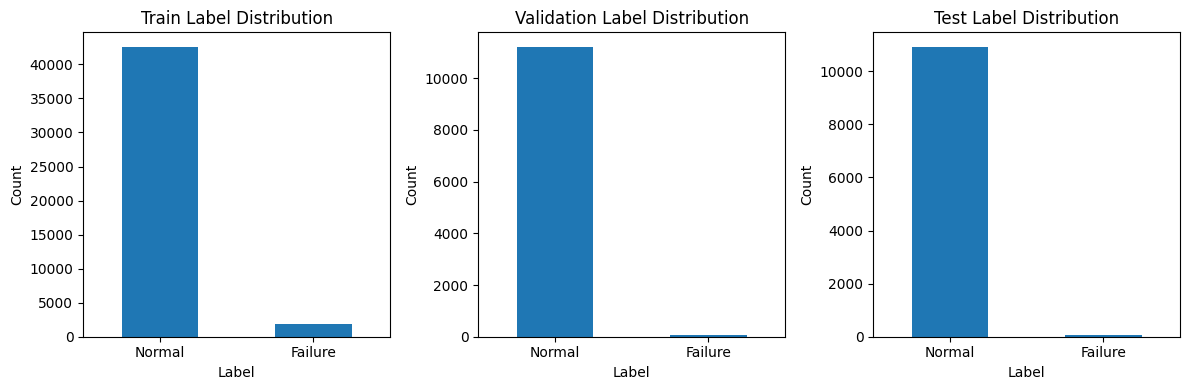

In [37]:
# Analyze label distribution in datasets
print("📊 Analyzing label distribution...")

# Calculate positive ratios
train_labels = train_ds.y.numpy()
val_labels = val_ds.y.numpy()
test_labels = test_ds.y.numpy()

train_pos_ratio = (train_labels == 1).mean()
val_pos_ratio = (val_labels == 1).mean()
test_pos_ratio = (test_labels == 1).mean()

print(f"✅ Label distribution analysis:")
print(f"   - Train positive ratio: {train_pos_ratio:.4f}")
print(f"   - Validation positive ratio: {val_pos_ratio:.4f}")
print(f"   - Test positive ratio: {test_pos_ratio:.4f}")

# Visualize label distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, labels, title in zip(
    axes,
    [train_labels, val_labels, test_labels],
    ["Train", "Validation", "Test"]
):
    counts = pd.Series(labels).value_counts().sort_index()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f"{title} Label Distribution")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.set_xticklabels(['Normal', 'Failure'], rotation=0)

plt.tight_layout()
plt.show()


## Data Loaders


In [38]:
print("🔄 Creating data loaders...")

# Training data loader
train_loader = DataLoader(
    train_ds,
    batch_size=training_params['batch_size'],
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows compatibility
    pin_memory=True,
    drop_last=True
)

# Training data loader for evaluation (no shuffle)
train_loader_eval = DataLoader(
    train_ds, 
    batch_size=1024, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

# Validation and test data loaders
val_loader = DataLoader(
    val_ds, 
    batch_size=1024, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

test_loader = DataLoader(
    test_ds, 
    batch_size=1024, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

print(f"✅ Data loaders created successfully")
print(f"   - Train loader: {len(train_loader)} batches (batch_size={training_params['batch_size']})")
print(f"   - Validation loader: {len(val_loader)} batches")
print(f"   - Test loader: {len(test_loader)} batches")


🔄 Creating data loaders...
✅ Data loaders created successfully
   - Train loader: 86 batches (batch_size=512)
   - Validation loader: 12 batches
   - Test loader: 11 batches


## Model Setup


In [39]:
print("🤖 Setting up model...")

# Create CNN-LSTM model
model = CNNLSTMModel(
    num_features=model_params['num_features'],
    cnn_out_channels=model_params['cnn_out_channels'],
    lstm_hidden_size=model_params['lstm_hidden_size'],
    lstm_layers=model_params['lstm_layers'],
    dropout=model_params['dropout']
)

# Create loss function
criterion = FocalLoss(alpha=0.75, gamma=2.0)

# Create optimizer
optimizer = AdamW(
    model.parameters(), 
    lr=training_params['learning_rate'], 
    weight_decay=training_params['weight_decay']
)

print(f"✅ Model setup completed")
print(f"   - Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   - Loss function: FocalLoss (alpha=0.75, gamma=2.0)")
print(f"   - Optimizer: AdamW (lr={training_params['learning_rate']}, weight_decay={training_params['weight_decay']})")


🤖 Setting up model...
✅ Model setup completed
   - Model parameters: 62,593
   - Loss function: FocalLoss (alpha=0.75, gamma=2.0)
   - Optimizer: AdamW (lr=0.0003, weight_decay=0.0001)


## Learning Rate Scheduler


In [40]:
print("📈 Setting up learning rate scheduler...")

# Calculate scheduler parameters
steps_per_epoch = len(train_loader)
max_epochs = training_params['num_epochs']
total_steps = steps_per_epoch * max_epochs
warmup_steps = max(1, int(total_steps * training_params['warmup_ratio']))

def lr_lambda(current_step):
    """Cosine annealing with warmup"""
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return 0.1 + 0.9 * cosine  # lower bound 0.1×

# Create scheduler
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"✅ Learning rate scheduler configured")
print(f"   - Total steps: {total_steps:,}")
print(f"   - Warmup steps: {warmup_steps:,}")
print(f"   - Steps per epoch: {steps_per_epoch}")
print(f"   - Max epochs: {max_epochs}")
print(f"   - Scheduler: Cosine annealing with warmup")


📈 Setting up learning rate scheduler...
✅ Learning rate scheduler configured
   - Total steps: 860
   - Warmup steps: 43
   - Steps per epoch: 86
   - Max epochs: 10
   - Scheduler: Cosine annealing with warmup


## Model Training


In [41]:
print("🚀 Starting model training...")

try:
    # Train the model
    training_log = train_loop(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        num_epochs=training_params['num_epochs'],
        log_interval=25,
        save_interval=1,
       # save_path='../model/refactored_training'
    )
    
    print(f"✅ Training completed successfully!")
    print(f"   - Training log saved to: ../model/refactored_training/")
    
except Exception as e:
    print(f"❌ Training failed: {e}")
    training_log = None


🚀 Starting model training...
Model moved to cuda
[Epoch 1] Step 0/86 - Loss: 0.0567
[Epoch 1] Step 25/86 - Loss: 0.0544
[Epoch 1] Step 50/86 - Loss: 0.0463
[Epoch 1] Step 75/86 - Loss: 0.0254
🔁 Epoch 1 finished. Avg Train Loss: 0.0450


Testing: 100%|██████████| 12/12 [00:00<00:00, 17.13it/s]


✅ avg_loss: 0.0136 | AUC-PR: 0.0069 | baseline: 0.0053 | uplift: 1.30x | P@50:0.000 R@50:0.000 | P@100:0.000 R@100:0.000 | P@200:0.005 R@200:0.017
Best model saved at epoch 1 with AUC-PR 0.0069
[Epoch 2] Step 0/86 - Loss: 0.0268
[Epoch 2] Step 25/86 - Loss: 0.0281
[Epoch 2] Step 50/86 - Loss: 0.0272
[Epoch 2] Step 75/86 - Loss: 0.0319
🔁 Epoch 2 finished. Avg Train Loss: 0.0276


Testing: 100%|██████████| 12/12 [00:00<00:00, 12.94it/s]


✅ avg_loss: 0.0120 | AUC-PR: 0.0712 | baseline: 0.0053 | uplift: 13.37x | P@50:0.100 R@50:0.083 | P@100:0.050 R@100:0.083 | P@200:0.040 R@200:0.133
Best model saved at epoch 2 with AUC-PR 0.0712
[Epoch 3] Step 0/86 - Loss: 0.0267
[Epoch 3] Step 25/86 - Loss: 0.0273
[Epoch 3] Step 50/86 - Loss: 0.0296
[Epoch 3] Step 75/86 - Loss: 0.0205
🔁 Epoch 3 finished. Avg Train Loss: 0.0242


...

✅ avg_loss: 0.0103 | AUC-PR: 0.0304 | baseline: 0.0053 | uplift: 5.71x | P@50:0.000 R@50:0.000 | P@100:0.000 R@100:0.000 | P@200:0.015 R@200:0.050
[Epoch 9] Step 0/86 - Loss: 0.0103
[Epoch 9] Step 25/86 - Loss: 0.0156
[Epoch 9] Step 50/86 - Loss: 0.0143
[Epoch 9] Step 75/86 - Loss: 0.0111
🔁 Epoch 9 finished. Avg Train Loss: 0.0148


Testing: 100%|██████████| 12/12 [00:00<00:00, 15.68it/s]


✅ avg_loss: 0.0105 | AUC-PR: 0.0348 | baseline: 0.0053 | uplift: 6.53x | P@50:0.000 R@50:0.000 | P@100:0.020 R@100:0.033 | P@200:0.025 R@200:0.083
[Epoch 10] Step 0/86 - Loss: 0.0104
[Epoch 10] Step 25/86 - Loss: 0.0157
[Epoch 10] Step 50/86 - Loss: 0.0129
[Epoch 10] Step 75/86 - Loss: 0.0151
🔁 Epoch 10 finished. Avg Train Loss: 0.0147


Testing: 100%|██████████| 12/12 [00:00<00:00, 15.84it/s]

✅ avg_loss: 0.0112 | AUC-PR: 0.0335 | baseline: 0.0053 | uplift: 6.28x | P@50:0.000 R@50:0.000 | P@100:0.020 R@100:0.033 | P@200:0.025 R@200:0.083
🏁 Training completed.
✅ Training completed successfully!
   - Training log saved to: ../model/refactored_training/


## Training Visualization


📊 Visualizing training progress...


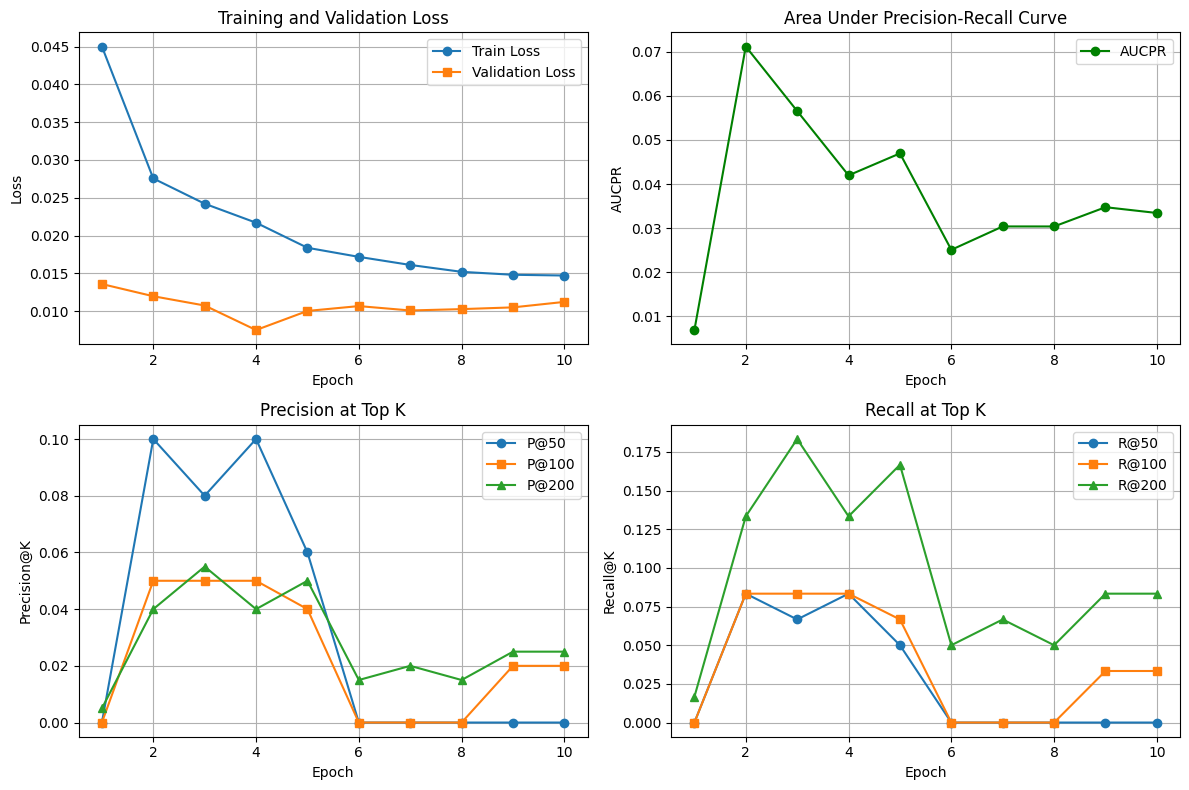

✅ Training visualization completed


In [42]:
if training_log is not None:
    print("📊 Visualizing training progress...")
    
    try:
        # Visualize training curves
        visualize_log(training_log)
        
        print("✅ Training visualization completed")
        
    except Exception as e:
        print(f"❌ Error in visualization: {e}")
else:
    print("⏭️ Skipping training visualization (no training log available)")


## Model Evaluation


📊 Evaluating model on training set...


Testing: 100%|██████████| 44/44 [00:02<00:00, 16.61it/s]


✅ Training set evaluation completed
   - Training Loss: 0.0162

📈 Training Set Performance:
Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.90      0.94     42584
     Failure       0.27      0.86      0.41      1920

    accuracy                           0.89     44504
   macro avg       0.63      0.88      0.68     44504
weighted avg       0.96      0.89      0.92     44504


Confusion Matrix:
[[38175  4409]
 [  266  1654]]

ROC AUC: 0.9018


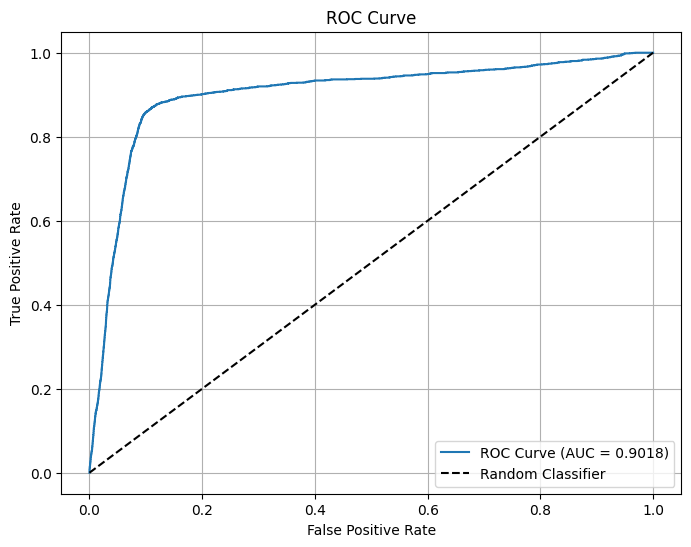

In [43]:
print("📊 Evaluating model on training set...")

try:
    # Evaluate on training set
    train_trues, train_outputs, train_loss = test_loop(
        model, 
        train_loader_eval, 
        criterion=criterion
    )
    
    # Convert outputs to predictions
    train_predictions = (train_outputs > 0.35).astype(int)
    
    print(f"✅ Training set evaluation completed")
    print(f"   - Training Loss: {train_loss:.4f}")
    
    # Generate comprehensive report
    print("\n📈 Training Set Performance:")
    generate_report(train_trues, train_predictions, train_outputs)
    
except Exception as e:
    print(f"❌ Error in training evaluation: {e}")


## Model Calibration


In [44]:
print("🔧 Performing model calibration...")

try:
    # Get logits and labels for validation and test sets
    val_logits, val_labels = get_logits_and_labels(model, val_loader)
    test_logits, test_labels = get_logits_and_labels(model, test_loader)
    
    # Convert logits to probabilities
    val_scores = torch.sigmoid(torch.tensor(val_logits)).numpy()
    test_scores = torch.sigmoid(torch.tensor(test_logits)).numpy()
    
    # Apply Platt scaling (logistic regression calibration)
    print("   - Applying Platt scaling...")
    platt_scaler = LogisticRegression(solver='lbfgs', class_weight='balanced')
    platt_scaler.fit(val_logits.reshape(-1, 1), val_labels)
    
    # Save the calibration scaler
    os.makedirs('../model', exist_ok=True)
    pickle.dump(platt_scaler, open("../model/platt_scaler.pkl", "wb"))
    
    # Get calibrated probabilities
    val_probs_calibrated = platt_scaler.predict_proba(val_logits.reshape(-1, 1))[:, 1]
    test_probs_calibrated = platt_scaler.predict_proba(test_logits.reshape(-1, 1))[:, 1]
    
    print(f"✅ Model calibration completed")
    print(f"   - Calibration scaler saved to: ../model/platt_scaler.pkl")
    
except Exception as e:
    print(f"❌ Error in model calibration: {e}")
    # Fallback to uncalibrated probabilities
    val_probs_calibrated = val_scores
    test_probs_calibrated = test_scores


🔧 Performing model calibration...
   - Applying Platt scaling...
✅ Model calibration completed
   - Calibration scaler saved to: ../model/platt_scaler.pkl


## Threshold Optimization


In [45]:
best_threshold = 0.5
val_preds = (val_probs_calibrated >= best_threshold).astype(int)
test_preds = (test_probs_calibrated >= best_threshold).astype(int)


## Final Evaluation


📊 Final model evaluation...

📈 Validation Set Performance:
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.84      0.91     11210
     Failure       0.03      1.00      0.06        60

    accuracy                           0.84     11270
   macro avg       0.52      0.92      0.49     11270
weighted avg       0.99      0.84      0.91     11270


Confusion Matrix:
[[9367 1843]
 [   0   60]]

ROC AUC: 0.9248


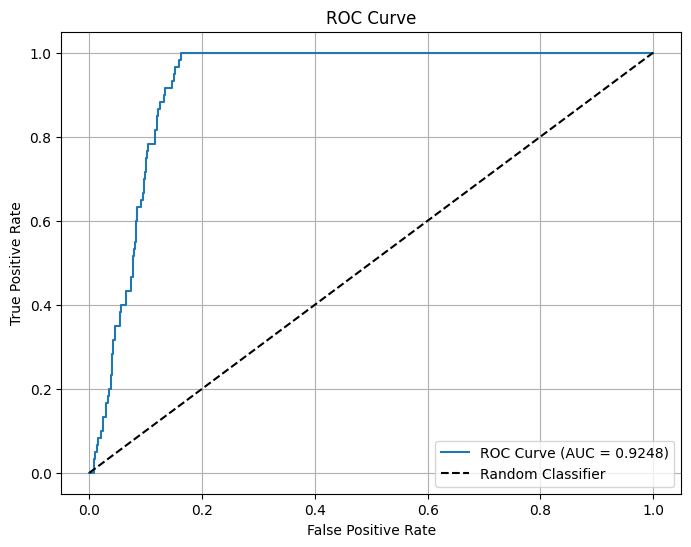


📈 Test Set Performance:
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94     10919
     Failure       0.02      0.50      0.05        60

    accuracy                           0.89     10979
   macro avg       0.51      0.69      0.49     10979
weighted avg       0.99      0.89      0.93     10979


Confusion Matrix:
[[9695 1224]
 [  30   30]]

ROC AUC: 0.7266


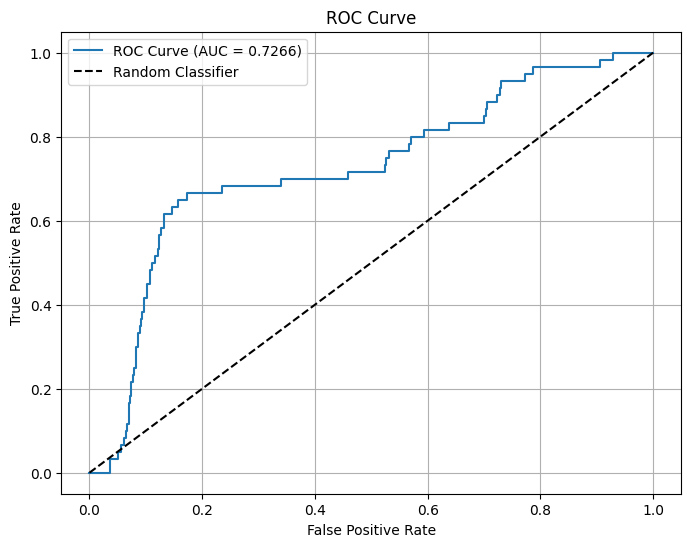


📈 Top-K Metrics:
Validation Set:
   - Precision@50: 0.0000
   - Recall@50: 0.0000
   - Precision@100: 0.0200
   - Recall@100: 0.0333
   - Precision@200: 0.0250
   - Recall@200: 0.0833
Test Set:
   - Precision@50: 0.0000
   - Recall@50: 0.0000
   - Precision@100: 0.0000
   - Recall@100: 0.0000
   - Precision@200: 0.0000
   - Recall@200: 0.0000


In [46]:
print("📊 Final model evaluation...")

# Validation set evaluation
print("\n📈 Validation Set Performance:")
try:
    generate_report(val_labels, val_preds, val_probs_calibrated)
except Exception as e:
    print(f"❌ Error in validation evaluation: {e}")

# Test set evaluation
print("\n📈 Test Set Performance:")
try:
    generate_report(test_labels, test_preds, test_probs_calibrated)
except Exception as e:
    print(f"❌ Error in test evaluation: {e}")

# Calculate Top-K metrics
print("\n📈 Top-K Metrics:")
try:
    # Validation set Top-K metrics
    val_topk = cal_topK_metrics(val_probs_calibrated, val_labels, top_k=(50, 100, 200))
    print("Validation Set:")
    for k in [50, 100, 200]:
        print(f"   - Precision@{k}: {val_topk[f'prec@{k}']:.4f}")
        print(f"   - Recall@{k}: {val_topk[f'rec@{k}']:.4f}")
    
    # Test set Top-K metrics
    test_topk = cal_topK_metrics(test_probs_calibrated, test_labels, top_k=(50, 100, 200))
    print("Test Set:")
    for k in [50, 100, 200]:
        print(f"   - Precision@{k}: {test_topk[f'prec@{k}']:.4f}")
        print(f"   - Recall@{k}: {test_topk[f'rec@{k}']:.4f}")
        
except Exception as e:
    print(f"❌ Error in Top-K metrics calculation: {e}")


## Summary

This notebook demonstrates the complete model training pipeline using the refactored package:

1. **Configuration Loading**: Load dataset parameters and set model/training configurations
2. **Data Loading**: Load preprocessed CSV datasets
3. **Dataset Creation**: Create specialized PyTorch datasets with different sampling strategies
4. **Data Loaders**: Set up efficient data loaders for training and evaluation
5. **Model Setup**: Initialize CNN-LSTM model with FocalLoss and AdamW optimizer
6. **Learning Rate Scheduling**: Configure cosine annealing with warmup
7. **Model Training**: Train the model with comprehensive logging
8. **Training Visualization**: Visualize training progress and metrics
9. **Model Evaluation**: Evaluate model performance on training set
10. **Model Calibration**: Apply Platt scaling for probability calibration
11. **Threshold Optimization**: Find optimal classification threshold
12. **Final Evaluation**: Comprehensive evaluation with Top-K metrics

The refactored package provides:
- **Modular Design**: Clean separation of dataset, model, training, and evaluation components
- **Type Safety**: Comprehensive type hints throughout
- **Error Handling**: Robust error handling and informative messages
- **Advanced Metrics**: Top-K accuracy and comprehensive evaluation metrics
- **Calibration**: Built-in probability calibration capabilities

The trained model and calibration scaler are saved for future inference tasks.
